# Methodology of Cost estimation


### Preliminaries

 - Analysis of the apertus 8b and 70b to get insights

#### Userbase Analysis

In [26]:
import glob
import pandas as pd


models_of_interest = ["apertus-8b-instruct","apertus-70b-instruct"]

moi = models_of_interest[1:2]
# 1. Collect files
files = glob.glob("../data/litellm/public.LiteLLM_SpendLogs/1/*.parquet")


df_list = []
for file in files:
    temp_df = pd.read_parquet(file)
    temp_df = temp_df[temp_df["model"].isin(moi)]
    temp_df = temp_df[temp_df["status"] == "success"]

    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# 2. Define the columns you want to KEEP
keep_cols = [
    "model",
    "startTime",
    "endTime",
    "completionStartTime",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
    "end_user",
]

# Keep ONLY those (ignore missing if any file doesn't have it)
df = df[[c for c in keep_cols if c in df.columns]].copy()

# 3. Parse timestamps and sort
df["startTime"] = pd.to_datetime(df["startTime"],format = "mixed")
df = df.sort_values("startTime")

# 4. Compute inter-arrival times (Δ between current and previous request)
df["interarrival_seconds"] = df["startTime"].diff().dt.total_seconds()


print(df.shape)
df.tail() ## no day is multiple times since it starts 02.09. and ends 01.10. so its exactly one month




(103729, 9)


,model,startTime,endTime,completionStartTime,prompt_tokens,completion_tokens,total_tokens,end_user,interarrival_seconds
103724,apertus-70b-instruct,2025-10-01 03:27:12.190,2025-10-01 03:27:14.188,2025-10-01 03:27:12.363,773,86,859,enduser_eb40d354,63.785
103725,apertus-70b-instruct,2025-10-01 03:31:09.197,2025-10-01 03:31:35.581,2025-10-01 03:31:09.371,785,1191,1976,enduser_a22bfe8e,237.007
103726,apertus-70b-instruct,2025-10-01 03:31:44.785,2025-10-01 03:32:54.597,2025-10-01 03:31:45.109,1897,3052,4949,enduser_583ba19e,35.588
103727,apertus-70b-instruct,2025-10-01 03:31:52.958,2025-10-01 03:32:04.954,2025-10-01 03:32:04.953,1216,537,1753,enduser_d41d8cd9,8.173
103728,apertus-70b-instruct,2025-10-01 03:33:23.783,2025-10-01 03:33:34.514,2025-10-01 03:33:34.514,1119,500,1619,enduser_d41d8cd9,90.825


### User Analysis

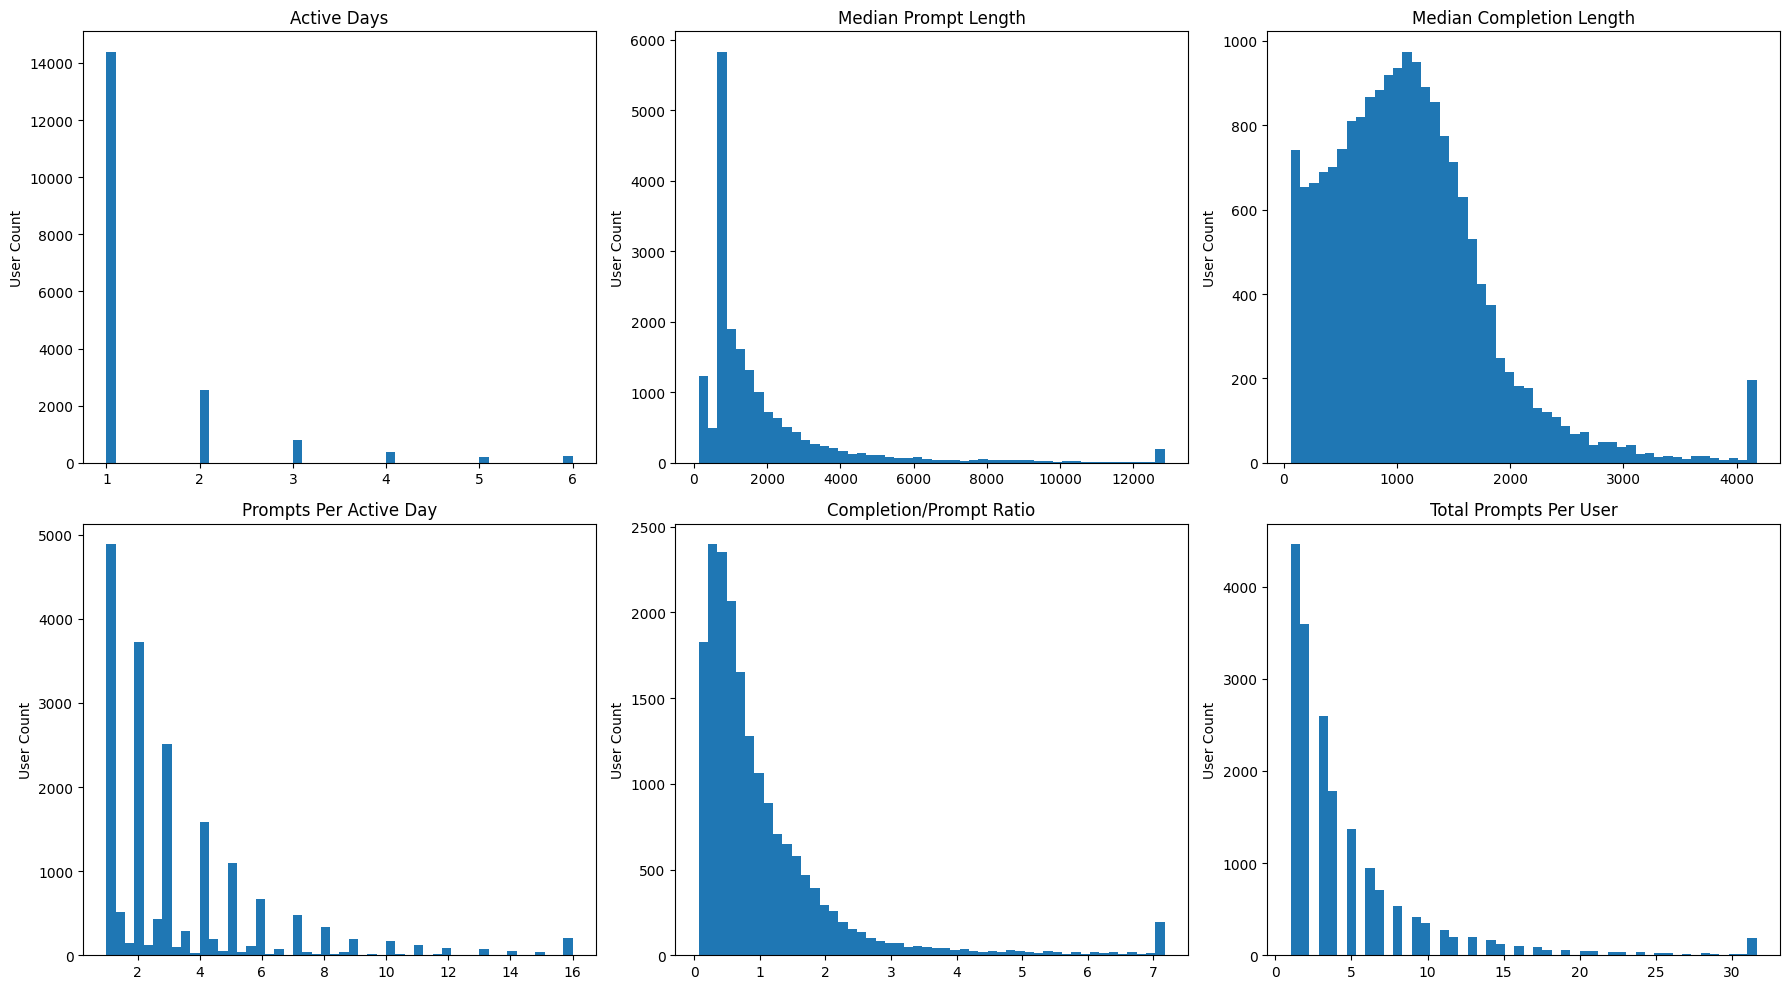

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_ = df.copy()

# Ensure datetime
df_["startTime"] = pd.to_datetime(df_["startTime"])

# --- 1. ACTIVE DAYS PER USER ---
active_days = (
    df_.groupby("end_user")["startTime"]
      .apply(lambda x: x.dt.date.nunique())
      .rename("active_days")
)

# --- 2. MEDIAN PROMPT LENGTH ---
median_prompt_len = (
    df_.groupby("end_user")["prompt_tokens"]
      .median()
      .rename("median_prompt_tokens")
)

# --- 3. MEDIAN COMPLETION LENGTH ---
median_completion_len = (
    df_.groupby("end_user")["completion_tokens"]
      .median()
      .rename("median_completion_tokens")
)

# --- 4. PROMPTS PER ACTIVE DAY ---
prompts_per_day = (
    (df_.groupby("end_user").size() / active_days)
    .rename("prompts_per_active_day")
)

# --- 5. OUTPUT / INPUT RATIO ---
ratio = (
    (df_["completion_tokens"] / df_["prompt_tokens"])
    .replace([float('inf'), float('nan')], 0)
)

median_ratio = (
    ratio.groupby(df_["end_user"]).median().rename("median_ratio")
)

# --- 6. TOTAL PROMPTS PER USER ---
total_prompts = df_.groupby("end_user").size().rename("total_prompts")

# Combine user-level stats
user_stats = pd.concat([
    active_days,
    median_prompt_len,
    median_completion_len,
    prompts_per_day,
    median_ratio,
    total_prompts
], axis=1)

# ---- SIMPLE OUTLIER CLIPPER ----
def clip_outliers(s):
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    return s.clip(lower, upper)

# -------------------------------
# PLOT HISTOGRAMS
# -------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cols = [
    "active_days",
    "median_prompt_tokens",
    "median_completion_tokens",
    "prompts_per_active_day",
    "median_ratio",
    "total_prompts"
]

titles = [
    "Active Days",
    "Median Prompt Length",
    "Median Completion Length",
    "Prompts Per Active Day",
    "Completion/Prompt Ratio",
    "Total Prompts Per User"
]

# USER-LEVEL HISTOGRAMS
for ax, col, title in zip(axes[:6], cols, titles):
    data = clip_outliers(user_stats[col])
    ax.hist(data, bins=50)
    ax.set_title(title)
    ax.set_ylabel("User Count")


plt.tight_layout()
plt.show()


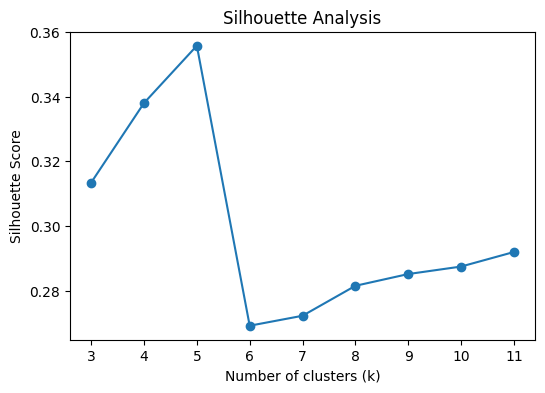

Best number of clusters: 5


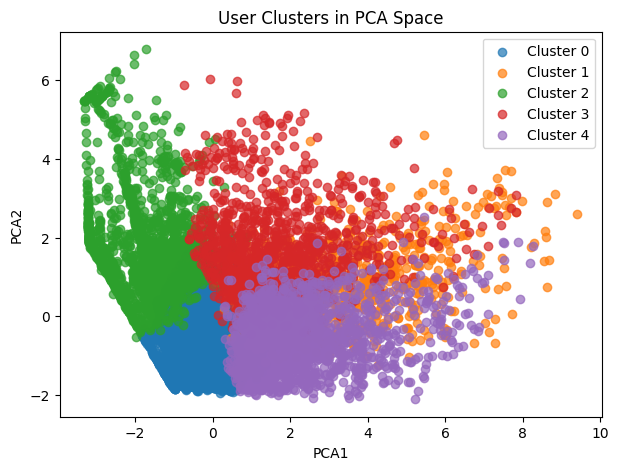

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns

# --- CLEAN DATA FOR CLUSTERING ---
df_ = user_stats.copy()
# optional: clip outliers for stability
def clip_outliers(s):
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    return s.clip(lower, upper)

df_clean = df_.apply(clip_outliers)
# standardize features
scaler = StandardScaler()
X = scaler.fit_transform(df_clean)

# --- SILHOUETTE ANALYSIS ---
sil_scores = {}
K_range = range(3, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores[k] = sil

# Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

# --- CHOOSE BEST K ---
best_k = max(sil_scores, key=sil_scores.get)
print(f"Best number of clusters: {best_k}")

# --- FINAL KMEANS ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X)
df_clean["cluster"] = cluster_labels

# --- PCA FOR 2D VISUALIZATION ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))
for c in range(best_k):
    plt.scatter(X_pca[df_clean["cluster"]==c, 0], 
                X_pca[df_clean["cluster"]==c, 1], 
                label=f"Cluster {c}", alpha=0.7)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("User Clusters in PCA Space")
plt.legend()
plt.show()




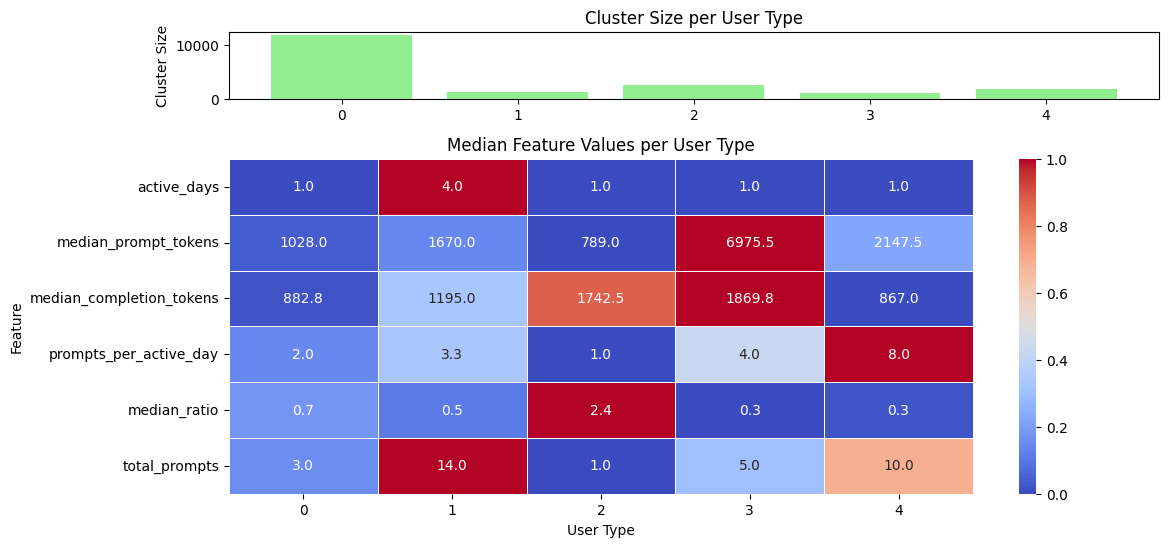

In [46]:
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# --- MEDIAN FEATURE TABLE PER CLUSTER ---
median_table = df_clean.groupby("cluster").median()

# --- CLUSTER SIZE ---
cluster_sizes = df_clean.groupby("cluster").size()

# Normalize features individually
median_norm = median_table.copy()
scaler = MinMaxScaler()
median_norm[:] = scaler.fit_transform(median_table)

# Transpose for plotting: features on y-axis, clusters on x-axis
median_norm_T = median_norm.T

# Plot setup
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(2,1, height_ratios=[1,5], hspace=0.3)

# Top: cluster size bar plot
ax0 = fig.add_subplot(gs[0])
ax0.bar(cluster_sizes.index, cluster_sizes.values, color="lightgreen")
ax0.set_ylabel("Cluster Size")
ax0.set_xticks(cluster_sizes.index)
ax0.set_title("Cluster Size per User Type")

# Bottom: heatmap of features
ax1 = fig.add_subplot(gs[1])
sns.heatmap(median_norm_T, annot=median_table.T, fmt=".1f", cmap="coolwarm", ax=ax1, linewidths=0.5)
ax1.set_xlabel("User Type")
ax1.set_ylabel("Feature")
ax1.set_title("Median Feature Values per User Type")

plt.show()


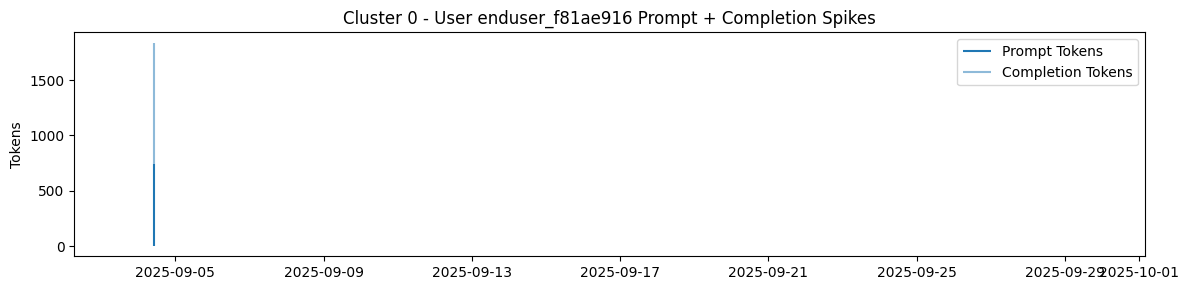

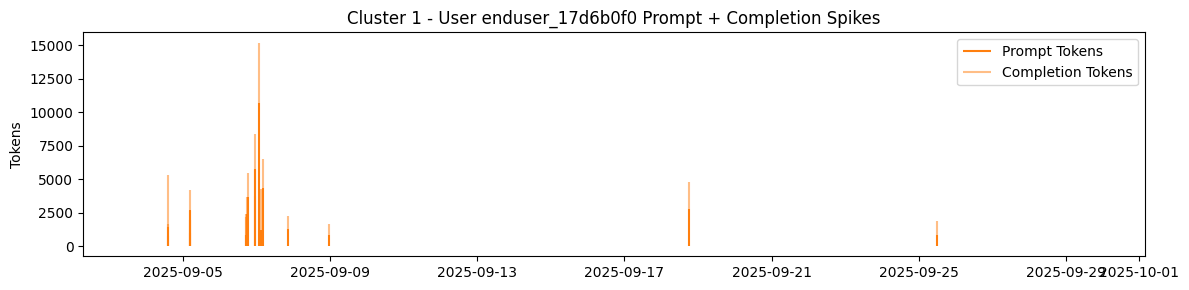

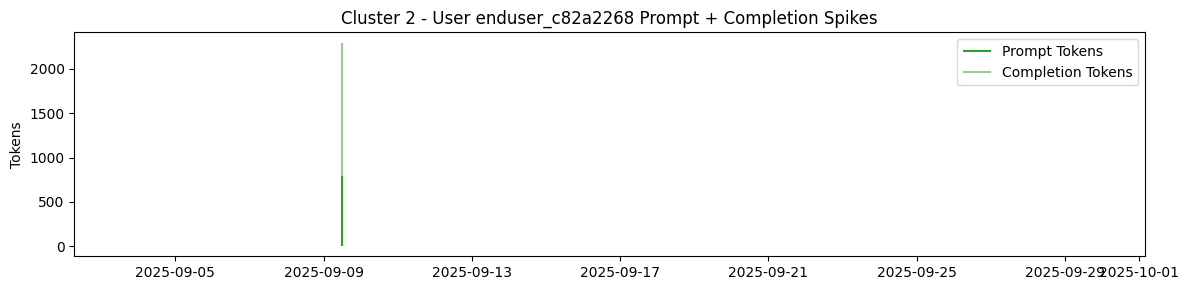

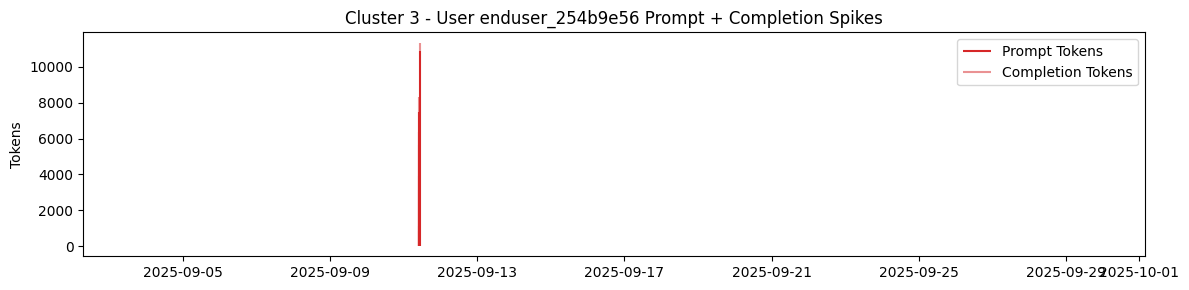

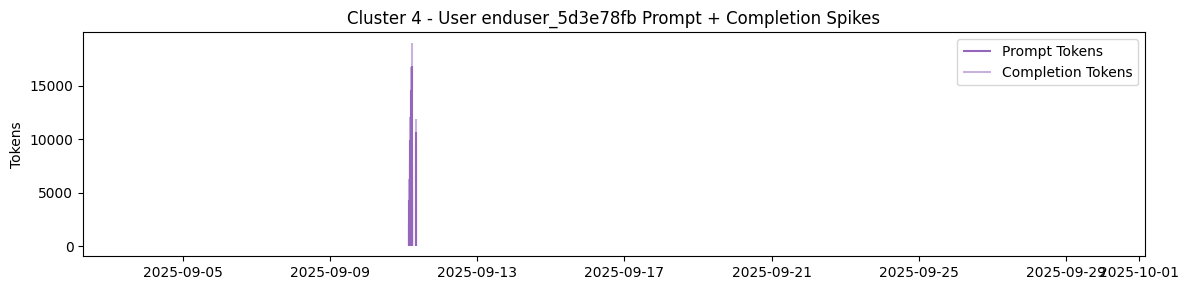

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a random user from each cluster
random_users = df_clean.groupby("cluster")["end_user"].apply(lambda x: np.random.choice(x.unique()))
clusters = random_users.index

# Global x-axis limits
min_time = df["startTime"].min()
max_time = df["startTime"].max()

colors = plt.cm.tab10.colors  # distinct colors per cluster

for i, cluster_label in enumerate(clusters):
    user_id = random_users[cluster_label]
    user_df = df[df["end_user"] == user_id].sort_values("startTime")
    
    plt.figure(figsize=(12, 3))  # slightly taller
    
    # Base spike = prompt tokens
    plt.vlines(user_df["startTime"], ymin=0, ymax=user_df["prompt_tokens"], 
               color=colors[i % len(colors)], label="Prompt Tokens")
    
    # Upper spike = completion tokens
    plt.vlines(user_df["startTime"], ymin=user_df["prompt_tokens"], 
               ymax=user_df["prompt_tokens"] + user_df["completion_tokens"],
               color=colors[i % len(colors)], alpha=0.5, label="Completion Tokens")
    
    plt.xlim(min_time, max_time)
    plt.ylabel("Tokens")
    plt.title(f"Cluster {cluster_label} - User {user_id} Prompt + Completion Spikes")
    
    # Show legend only once per figure
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc="upper right")
    
    plt.tight_layout()
    plt.show()


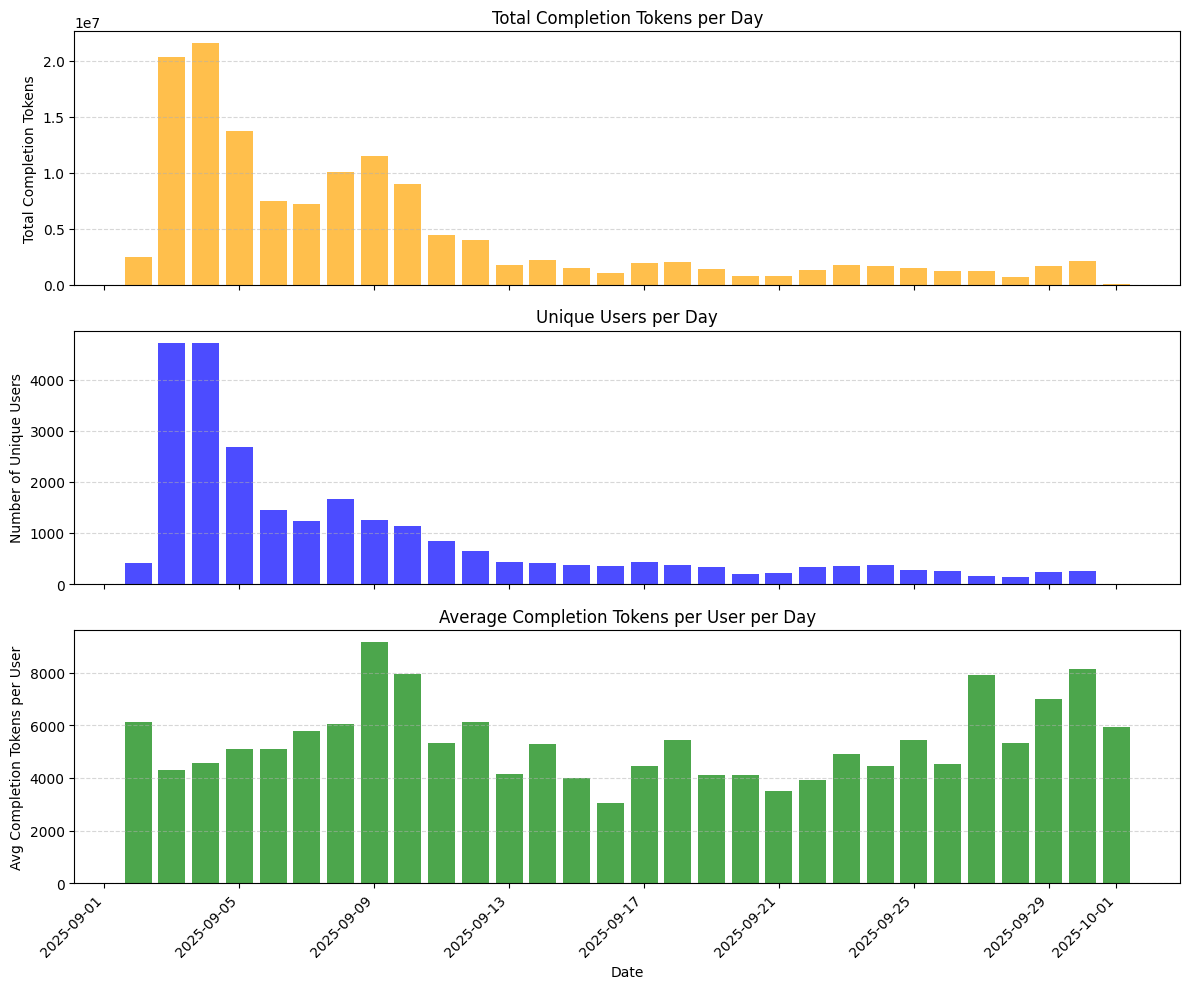

In [109]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime
df["startTime"] = pd.to_datetime(df["startTime"], format="mixed")

# Extract date
df["date"] = df["startTime"].dt.date

# Aggregate per day
daily_stats = df.groupby("date").agg(
    total_completion_tokens=("completion_tokens", "sum"),
    unique_users=("end_user", "nunique")
).reset_index()

# Compute average completion tokens per user
daily_stats["tokens_per_user"] = daily_stats["total_completion_tokens"] / daily_stats["unique_users"]

# Plot three subplots
fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

# Total completion tokens
axes[0].bar(daily_stats["date"], daily_stats["total_completion_tokens"], color="orange", alpha=0.7)
axes[0].set_ylabel("Total Completion Tokens")
axes[0].set_title("Total Completion Tokens per Day")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Number of unique users
axes[1].bar(daily_stats["date"], daily_stats["unique_users"], color="blue", alpha=0.7)
axes[1].set_ylabel("Number of Unique Users")
axes[1].set_title("Unique Users per Day")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Average tokens per user
axes[2].bar(daily_stats["date"], daily_stats["tokens_per_user"], color="green", alpha=0.7)
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Avg Completion Tokens per User")
axes[2].set_title("Average Completion Tokens per User per Day")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

# Improve layout
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\lukas\AppData\Local\Temp\ipykernel_21372\3013596329.py:13: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



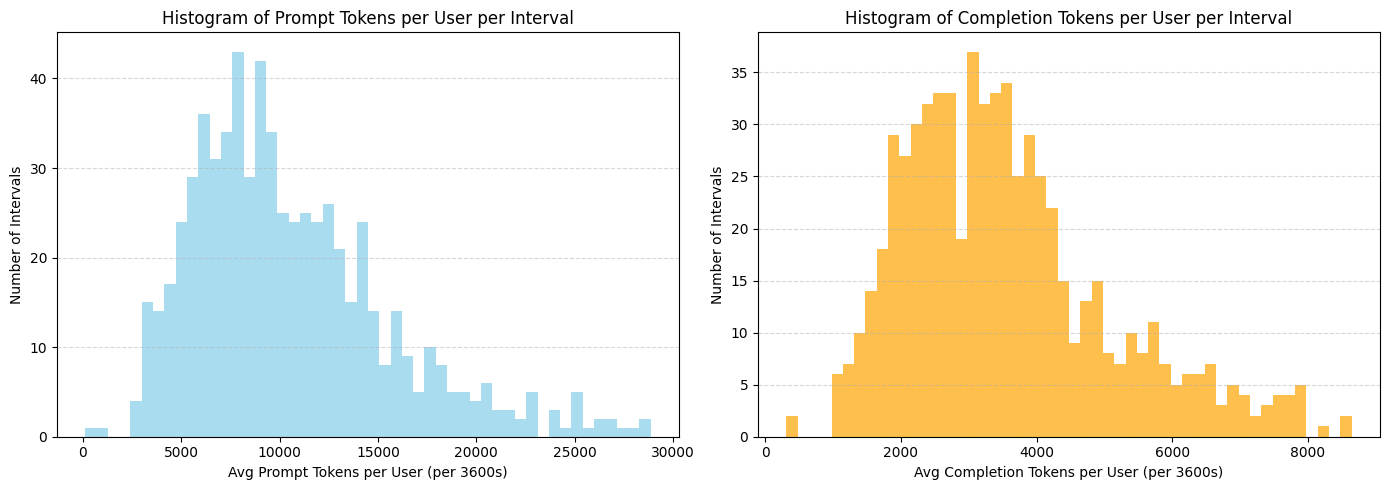

In [122]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Interval length in seconds
interval_seconds = 3600  # example: 10 minutes

# Ensure datetime
df["startTime"] = pd.to_datetime(df["startTime"], format="mixed")
df["endTime"] = pd.to_datetime(df["endTime"], format="mixed")

# Timestamp in seconds since epoch
df["start_sec"] = df["startTime"].view('int64') // 10**9

# Interval boundaries
start_time = df["start_sec"].min()
end_time = df["start_sec"].max()
bins = np.arange(start_time, end_time + interval_seconds, interval_seconds)

# Assign each row to an interval
df["interval_idx"] = np.searchsorted(bins, df["start_sec"], side="right") - 1

# Aggregate per interval
interval_stats = df.groupby("interval_idx").agg(
    total_completion_tokens=("completion_tokens", "sum"),
    total_prompt_tokens=("prompt_tokens", "sum"),
    unique_users=("end_user", "nunique")
).reset_index()

# Remove empty intervals
interval_stats = interval_stats[interval_stats["unique_users"] > 0]

# Compute average tokens per user per interval
interval_stats["completion_tokens_per_user"] = interval_stats["total_completion_tokens"] / interval_stats["unique_users"]
interval_stats["prompt_tokens_per_user"] = interval_stats["total_prompt_tokens"] / interval_stats["unique_users"]

# Filter out top 1% outliers for cleaner plots
comp_threshold = interval_stats["completion_tokens_per_user"].quantile(0.95)
prompt_threshold = interval_stats["prompt_tokens_per_user"].quantile(0.95)
comp_filtered = interval_stats[interval_stats["completion_tokens_per_user"] <= comp_threshold]["completion_tokens_per_user"]
prompt_filtered = interval_stats[interval_stats["prompt_tokens_per_user"] <= prompt_threshold]["prompt_tokens_per_user"]

# Plot histograms side by side
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.hist(prompt_filtered, bins=50, color="skyblue", alpha=0.7)
plt.xlabel(f"Avg Prompt Tokens per User (per {interval_seconds}s)")
plt.ylabel("Number of Intervals")
plt.title("Histogram of Prompt Tokens per User per Interval")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.subplot(1,2,2)
plt.hist(comp_filtered, bins=50, color="orange", alpha=0.7)
plt.xlabel(f"Avg Completion Tokens per User (per {interval_seconds}s)")
plt.ylabel("Number of Intervals")
plt.title("Histogram of Completion Tokens per User per Interval")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### Apertus Model Benchmarking

 - AWS EC2

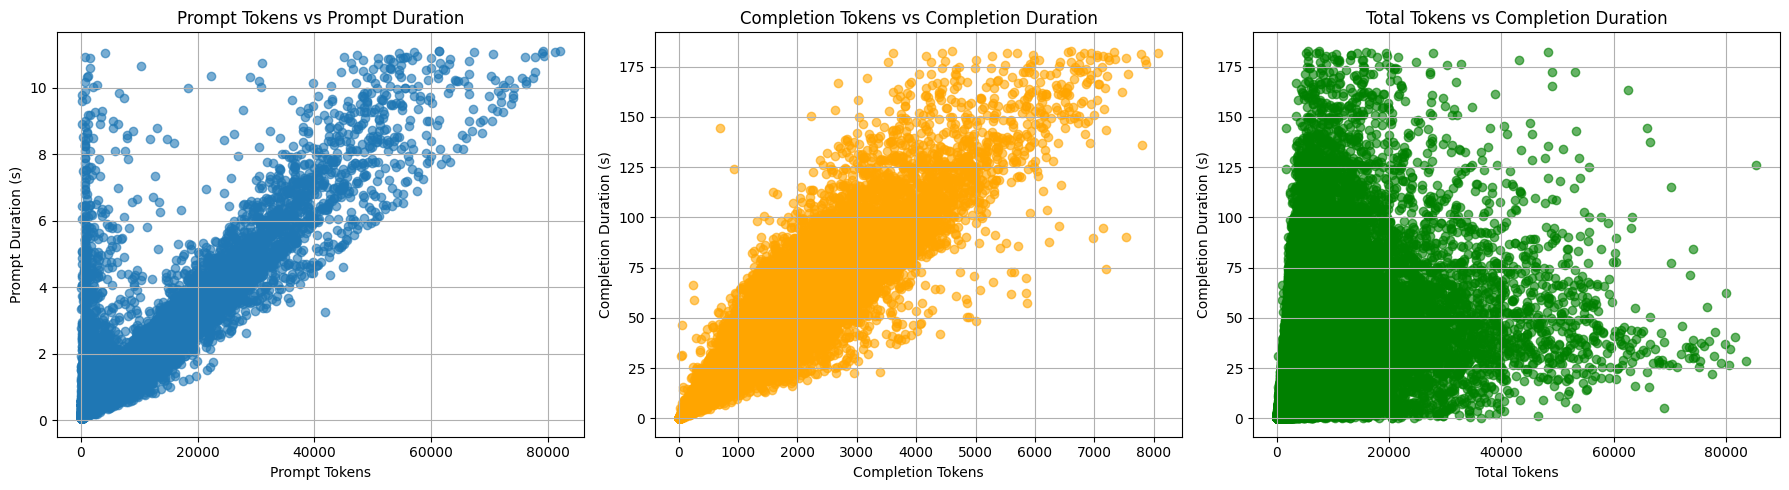

In [73]:
import matplotlib.pyplot as plt

# Compute durations

df["prompt_duration_seconds"] = (pd.to_datetime(df["completionStartTime"],format = "mixed") - pd.to_datetime(df["startTime"],format = "mixed")).dt.total_seconds()
df["completion_duration_seconds"] = (pd.to_datetime(df["endTime"],format = "mixed") - pd.to_datetime(df["completionStartTime"],format = "mixed")).dt.total_seconds()

# Filter durations < 0.05s

df_filtered = df[(df["prompt_duration_seconds"] >= 0.05) & (df["completion_duration_seconds"] >= 0.05)].copy()

# Remove top 1% (99th percentile) of durations for each

prompt_upper = df_filtered["prompt_duration_seconds"].quantile(0.99)
completion_upper = df_filtered["completion_duration_seconds"].quantile(0.99)

df_filtered = df_filtered[
(df_filtered["prompt_duration_seconds"] <= prompt_upper) &
(df_filtered["completion_duration_seconds"] <= completion_upper)
]

# Create three scatter plots side by side

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Prompt tokens vs prompt duration

axes[0].scatter(df_filtered["prompt_tokens"], df_filtered["prompt_duration_seconds"], alpha=0.6)
axes[0].set_xlabel("Prompt Tokens")
axes[0].set_ylabel("Prompt Duration (s)")
axes[0].set_title("Prompt Tokens vs Prompt Duration")
axes[0].grid(True)

# Completion tokens vs completion duration

axes[1].scatter(df_filtered["completion_tokens"], df_filtered["completion_duration_seconds"], alpha=0.6, color="orange")
axes[1].set_xlabel("Completion Tokens")
axes[1].set_ylabel("Completion Duration (s)")
axes[1].set_title("Completion Tokens vs Completion Duration")
axes[1].grid(True)

# Total tokens vs completion duration

axes[2].scatter(df_filtered["total_tokens"], df_filtered["completion_duration_seconds"], alpha=0.6, color="green")
axes[2].set_xlabel("Total Tokens")
axes[2].set_ylabel("Completion Duration (s)")
axes[2].set_title("Total Tokens vs Completion Duration")
axes[2].grid(True)

plt.tight_layout()
plt.show()


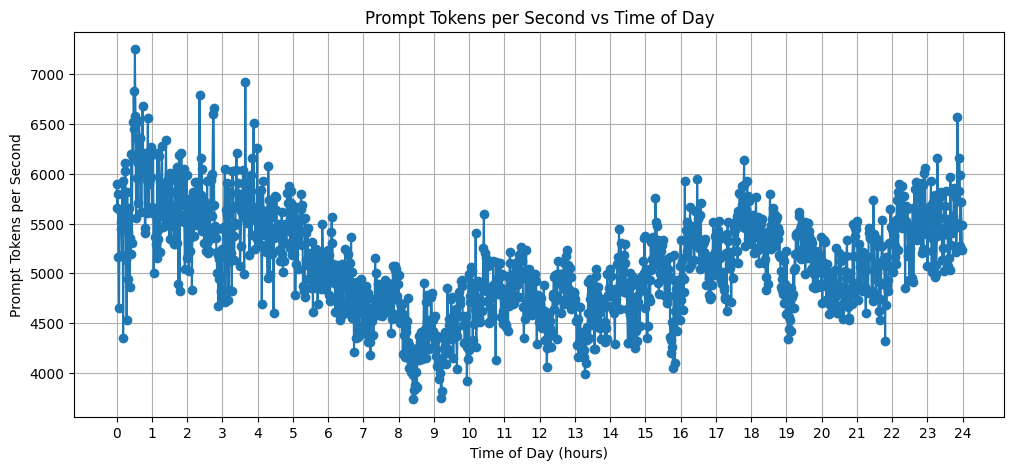

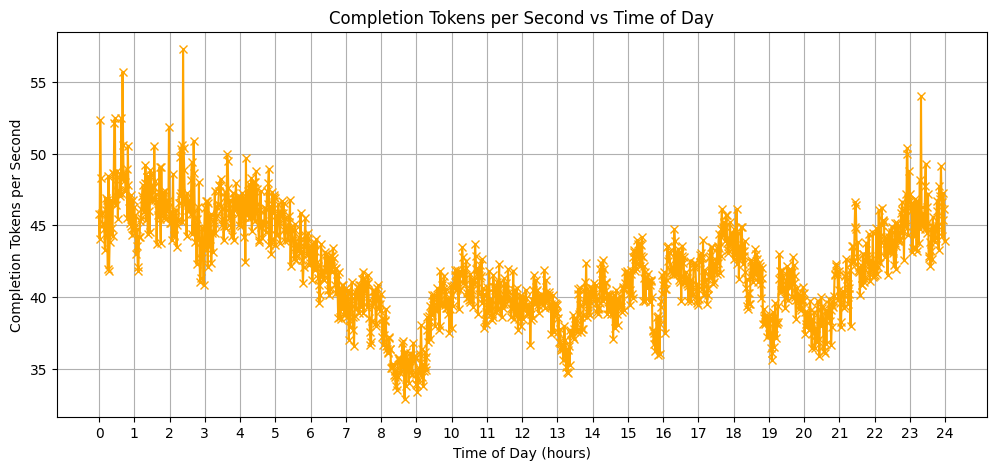

In [88]:
import matplotlib.pyplot as plt

# Compute tokens per second

df_filtered["prompt_tps"] = df_filtered["prompt_tokens"] / df_filtered["prompt_duration_seconds"]
df_filtered["completion_tps"] = df_filtered["completion_tokens"] / df_filtered["completion_duration_seconds"]

# Extract time-of-day as hour + minute fraction

df_filtered["time_of_day"] = df_filtered["startTime"].dt.hour + df_filtered["startTime"].dt.minute/60

# Aggregate by time-of-day (average across all days)

prompt_tps_by_time = df_filtered.groupby("time_of_day")["prompt_tps"].mean().reset_index()
completion_tps_by_time = df_filtered.groupby("time_of_day")["completion_tps"].mean().reset_index()

# Plot Prompt Tokens per Second

plt.figure(figsize=(12,5))
plt.plot(prompt_tps_by_time["time_of_day"], prompt_tps_by_time["prompt_tps"], marker='o')
plt.xlabel("Time of Day (hours)")
plt.ylabel("Prompt Tokens per Second")
plt.title("Prompt Tokens per Second vs Time of Day")
plt.grid(True)
plt.xticks(range(0,25))
plt.show()

# Plot Completion Tokens per Second

plt.figure(figsize=(12,5))
plt.plot(completion_tps_by_time["time_of_day"], completion_tps_by_time["completion_tps"], marker='x', color='orange')
plt.xlabel("Time of Day (hours)")
plt.ylabel("Completion Tokens per Second")
plt.title("Completion Tokens per Second vs Time of Day")
plt.grid(True)
plt.xticks(range(0,25))
plt.show()


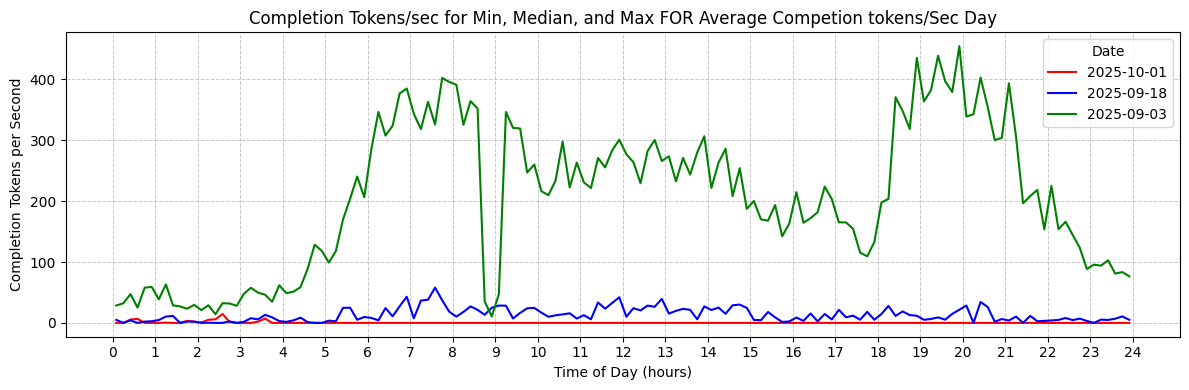

In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Interval length
interval_seconds = 10 * 60  # 10 minutes

# Ensure datetime
df_filtered["startTime"] = pd.to_datetime(df_filtered["startTime"], format="mixed")
df_filtered["endTime"] = pd.to_datetime(df_filtered["endTime"], format="mixed")

# Extract date
df_filtered["date"] = df_filtered["startTime"].dt.date

# Compute time-of-day in seconds
df_filtered["time_of_day_sec_start"] = df_filtered["startTime"].dt.hour*3600 + df_filtered["startTime"].dt.minute*60 + df_filtered["startTime"].dt.second
df_filtered["time_of_day_sec_end"] = df_filtered["endTime"].dt.hour*3600 + df_filtered["endTime"].dt.minute*60 + df_filtered["endTime"].dt.second

# Prepare bins
bins = np.arange(0, 24*3600 + interval_seconds, interval_seconds)
bin_centers = bins[:-1] + interval_seconds/2
time_of_day_hours = bin_centers / 3600

# Compute median completion tokens/sec per day
daily_medians = {}
dates = sorted(df_filtered["date"].unique())
for d in dates:
    df_day = df_filtered[df_filtered["date"] == d]
    completion_tps_list = []
    for start, end in zip(bins[:-1], bins[1:]):
        mask = (df_day["time_of_day_sec_start"] >= start) & (df_day["time_of_day_sec_end"] <= end)
        df_bin = df_day[mask]
        tps = df_bin["completion_tokens"].sum() / interval_seconds
        completion_tps_list.append(tps)
    daily_medians[d] = np.mean(completion_tps_list)

# Identify days with max, median, and min mean completion tokens/sec
median_values = list(daily_medians.values())
median_day_sorted = sorted(daily_medians.items(), key=lambda x: x[1])
min_day = median_day_sorted[0][0]
median_day = median_day_sorted[len(median_day_sorted)//2][0]
max_day = median_day_sorted[-1][0]

# Plot completion tokens/sec for these three days
plt.figure(figsize=(12,4))
for d, color in zip([min_day, median_day, max_day], ["red", "blue", "green"]):
    df_day = df_filtered[df_filtered["date"] == d]
    completion_tps_list = []
    for start, end in zip(bins[:-1], bins[1:]):
        mask = (df_day["time_of_day_sec_start"] >= start) & (df_day["time_of_day_sec_end"] <= end)
        df_bin = df_day[mask]
        tps = df_bin["completion_tokens"].sum() / interval_seconds
        completion_tps_list.append(tps)
    plt.plot(time_of_day_hours, completion_tps_list, label=f"{d}", color=color)

plt.xlabel("Time of Day (hours)")
plt.ylabel("Completion Tokens per Second")
plt.title("Completion Tokens/sec for Min, Median, and Max FOR Average Competion tokens/Sec Day")
plt.xticks(range(0,25))
plt.grid(which="both", linestyle="--", linewidth=0.7, alpha=0.7)
plt.legend(title="Date")
plt.tight_layout()
plt.show()


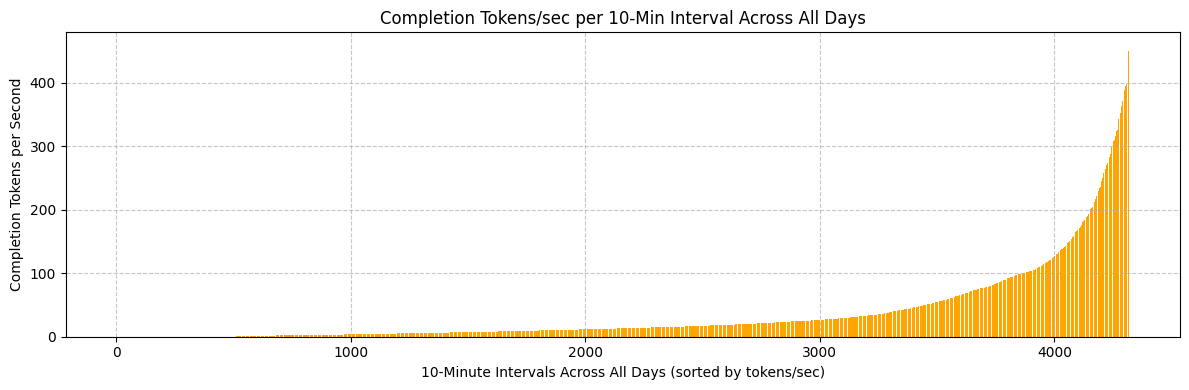

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Interval length
interval_seconds = 10 * 60  # 10 minutes

# Ensure datetime
df_filtered["startTime"] = pd.to_datetime(df_filtered["startTime"], format="mixed")
df_filtered["endTime"] = pd.to_datetime(df_filtered["endTime"], format="mixed")

# Time-of-day in seconds
df_filtered["time_sec_start"] = df_filtered["startTime"].dt.hour*3600 + df_filtered["startTime"].dt.minute*60 + df_filtered["startTime"].dt.second
df_filtered["time_sec_end"] = df_filtered["endTime"].dt.hour*3600 + df_filtered["endTime"].dt.minute*60 + df_filtered["endTime"].dt.second

# Create 10-minute bins (0-24 hours)
bins = np.arange(0, 24*3600 + interval_seconds, interval_seconds)

tokens_per_sec_all = []
interval_labels_all = []

# Iterate over all days
for d in sorted(df_filtered["date"].unique()):
    df_day = df_filtered[df_filtered["date"] == d].copy()
    for start, end in zip(bins[:-1], bins[1:]):
        # Only include requests fully contained in the interval
        mask = (df_day["time_sec_start"] >= start) & (df_day["time_sec_end"] <= end)
        df_bin = df_day[mask]
        total_tokens = df_bin["completion_tokens"].sum()
        tps = total_tokens / interval_seconds
        tokens_per_sec_all.append(tps)
        interval_labels_all.append(f"{d} {pd.to_timedelta(start, unit='s')} - {pd.to_timedelta(end, unit='s')}")

# Sort tokens/sec ascending
sorted_idx = np.argsort(tokens_per_sec_all)
tokens_per_sec_sorted = np.array(tokens_per_sec_all)[sorted_idx]
interval_labels_sorted = np.array(interval_labels_all)[sorted_idx]

# Plot
plt.figure(figsize=(12,4))
plt.bar(range(len(tokens_per_sec_sorted)), tokens_per_sec_sorted, color="orange")
plt.xlabel("10-Minute Intervals Across All Days (sorted by tokens/sec)")
plt.ylabel("Completion Tokens per Second")
plt.title("Completion Tokens/sec per 10-Min Interval Across All Days")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


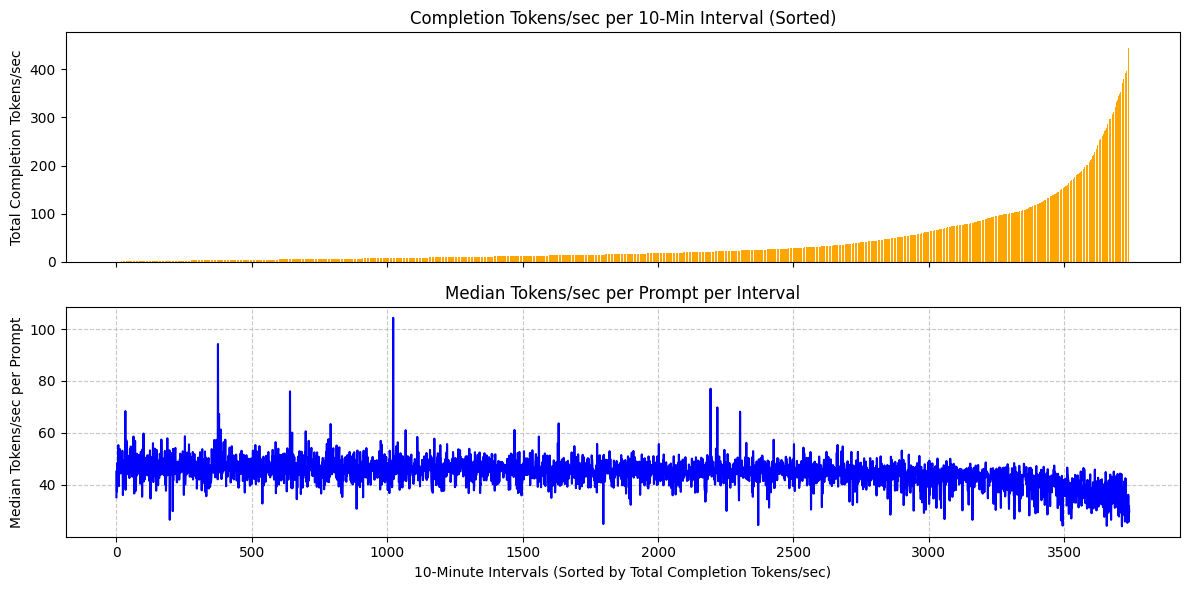

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Interval length
interval_seconds = 10 * 60  # 10 minutes

# Ensure datetime
df_filtered["startTime"] = pd.to_datetime(df_filtered["startTime"], format="mixed")
df_filtered["endTime"] = pd.to_datetime(df_filtered["endTime"], format="mixed")
df_filtered["completionStartTime"] = pd.to_datetime(df_filtered["completionStartTime"], format="mixed")

# Compute interval index
df_filtered["interval_idx"] = ((df_filtered["startTime"].dt.hour*3600 +
                                df_filtered["startTime"].dt.minute*60 +
                                df_filtered["startTime"].dt.second) // interval_seconds).astype(int)

# Only keep rows fully contained in the interval
df_filtered["time_sec_end"] = df_filtered["endTime"].dt.hour*3600 + df_filtered["endTime"].dt.minute*60 + df_filtered["endTime"].dt.second
df_filtered = df_filtered[df_filtered["time_sec_end"] <= (df_filtered["interval_idx"]+1)*interval_seconds]

# Compute per-prompt tokens/sec (normalized by completion latency)
df_filtered["prompt_tps"] = df_filtered["completion_tokens"] / (df_filtered["endTime"] - df_filtered["completionStartTime"]).dt.total_seconds()

# Aggregate by interval
interval_group = df_filtered.groupby(["date", "interval_idx"])
total_tps = interval_group["completion_tokens"].sum() / interval_seconds
median_user_tps = interval_group["prompt_tps"].median()

# Keep only non-empty intervals
non_empty_idx = total_tps > 0
total_tps = total_tps[non_empty_idx]
median_user_tps = median_user_tps[non_empty_idx]

# Sort intervals by total completion tokens/sec
sorted_idx = np.argsort(total_tps.values)
total_tps_sorted = total_tps.values[sorted_idx]
median_user_tps_sorted = median_user_tps.values[sorted_idx]

# Interval labels (optional)
interval_labels_sorted = [f"{d} {idx*interval_seconds//3600:02d}:{(idx*interval_seconds//60)%60:02d}" 
                          for (d, idx) in total_tps.index[sorted_idx]]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# Top plot: total completion tokens/sec
ax1.bar(range(len(total_tps_sorted)), total_tps_sorted, color="orange")
ax1.set_ylabel("Total Completion Tokens/sec")
ax1.set_title("Completion Tokens/sec per 10-Min Interval (Sorted)")

# Bottom plot: median tokens/sec per prompt in interval
ax2.plot(range(len(median_user_tps_sorted)), median_user_tps_sorted, color="blue")
ax2.set_xlabel("10-Minute Intervals (Sorted by Total Completion Tokens/sec)")
ax2.set_ylabel("Median Tokens/sec per Prompt")
ax2.set_title("Median Tokens/sec per Prompt per Interval")
ax2.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
